In [3]:
import anndata as ad
import pooch
import scanpy as sc

In [4]:
sc.set_figure_params(dpi=50, facecolor="white")

### Baixando os dados para pré-processamento e agrupamento

In [5]:
def download_sample(sample_id: str, known_hash: str) -> ad.AnnData:
    path = pooch.retrieve(
        path=pooch.os_cache("scverse_tutorials"),
        url=f"https://exampledata.scverse.org/tutorials/neurips-2021/{sample_id}_filtered_feature_bc_matrix.h5",
        known_hash=known_hash,
    )
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    return sample_adata

samples = {
    "s1d1": "md5:a99285913ea3f3d22600d3d2f8a88e34",
    "s1d3": "md5:825f7f7578e3dc0b8955f5a97a402338",
}
adatas = {id_: download_sample(id_, known_hash) for id_, known_hash in samples.items()}
adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observatio

### Controle de qualidade

In [6]:
# mitocondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# ribossomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# hemoblobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")


In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

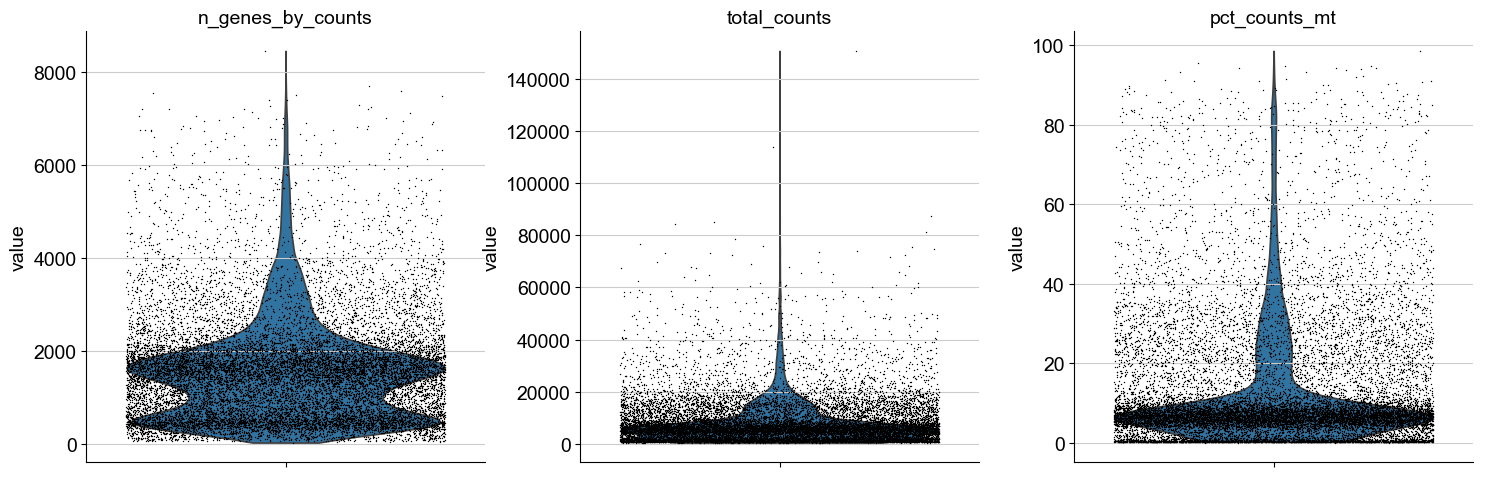

In [8]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True,)

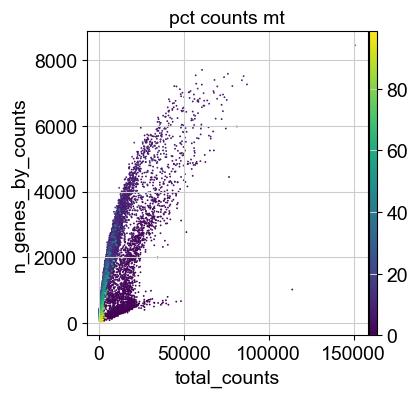

In [9]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [10]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

### Detecção de dupletos

In [11]:
sc.pp.scrublet(adata, batch_key="sample")

### Normalização

In [12]:
adata.layers["counts"] = adata.X.copy()

In [13]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

### Seleção de recursos

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

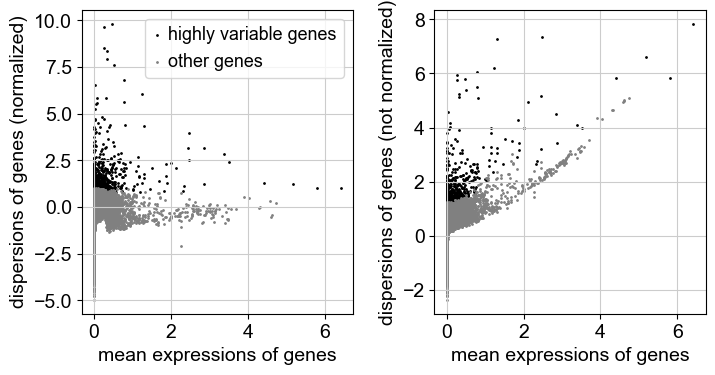

In [15]:
sc.pl.highly_variable_genes(adata)

### Redução de dimensionalidade 

In [16]:
sc.tl.pca(adata)

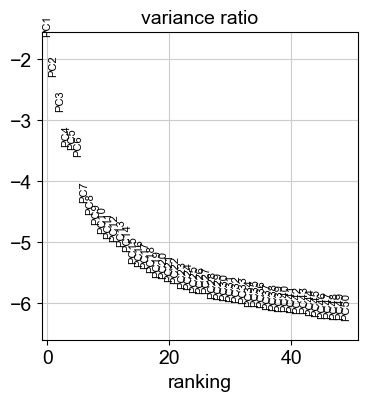

In [17]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### Visualização

In [18]:
sc.pp.neighbors(adata)

In [19]:
sc.tl.umap(adata)

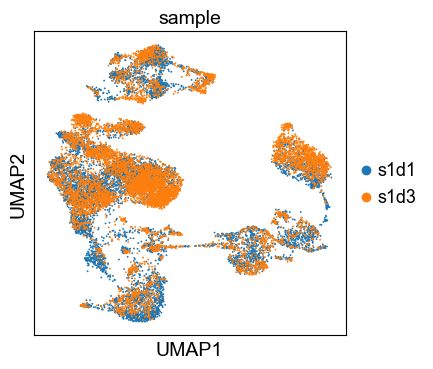

In [20]:
sc.pl.umap(adata, color="sample")

### Agrupamento

In [21]:
sc.tl.leiden(adata, flavor="igraph")

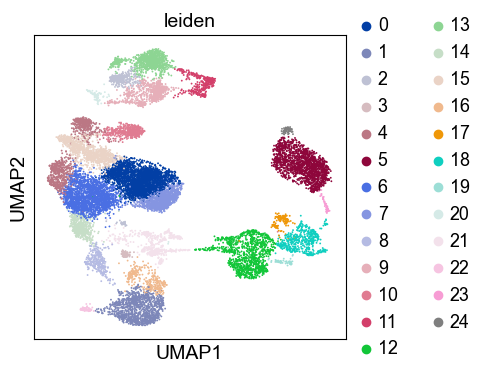

In [22]:
sc.pl.umap(adata, color=["leiden"])

### Reavaliar o controle de qualidade e a filtragem celular 

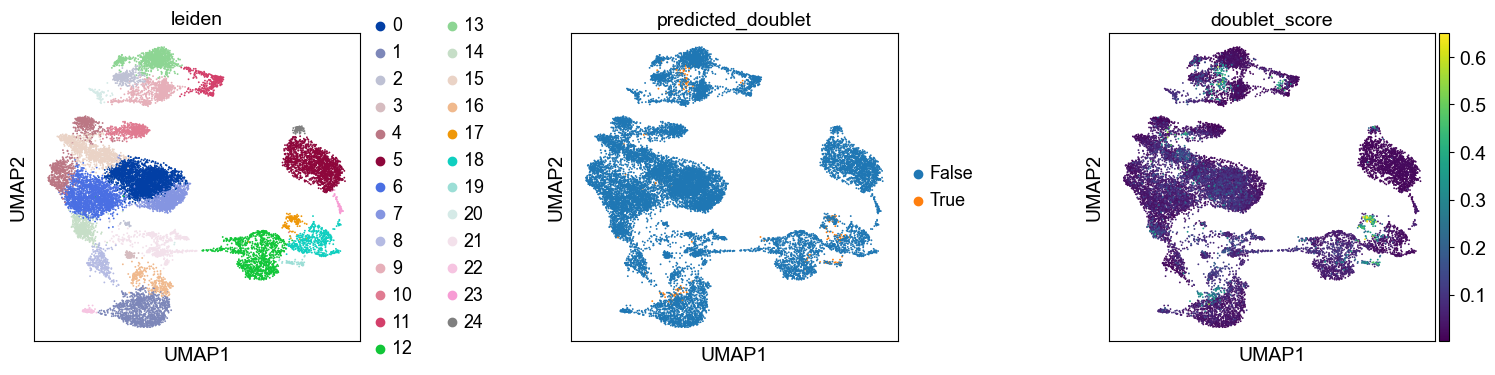

In [23]:
adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    wspace=0.5,
)

In [24]:
adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

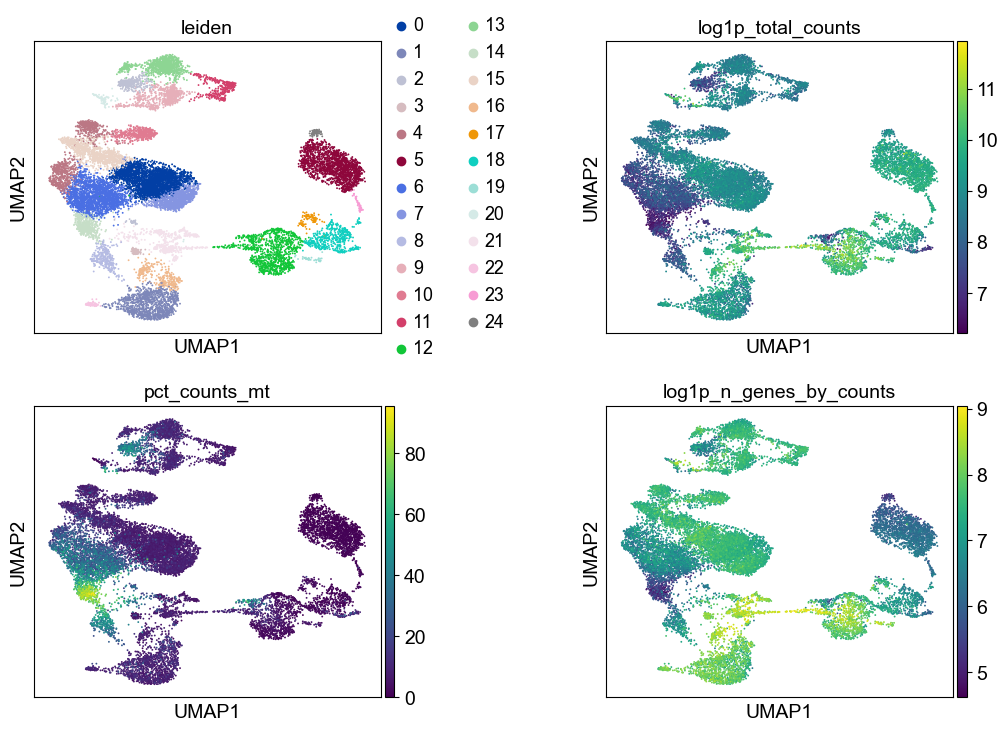

In [25]:
sc.pl.umap(
    adata, color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"], wspace=0.5, ncols=2
)

### Anotação do tipo de célula 

In [26]:
import celltypist as ct
import decoupler as dc

c:\Users\Davi\miniconda3\envs\tcell_env\lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [27]:
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res2", resolution=2)

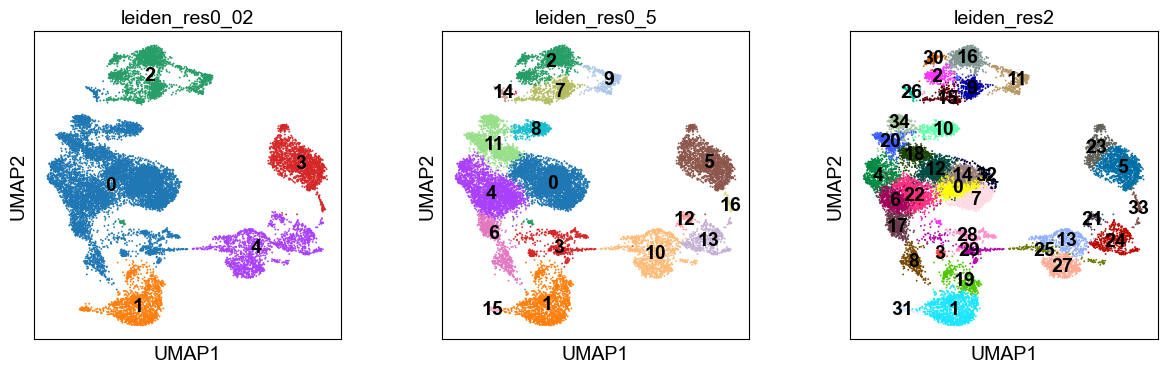

In [28]:
sc.pl.umap(
    adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data",
)

### Conjunto de genes marcadores 

In [29]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [31]:
def group_max(adata: sc.AnnData, groupby: str) -> str:
    import pandas as pd

    agg = sc.get.aggregate(adata, by=groupby, func="mean")
    return pd.Series(agg.layers["mean"].sum(1), agg.obg[groupby]).idxmax()

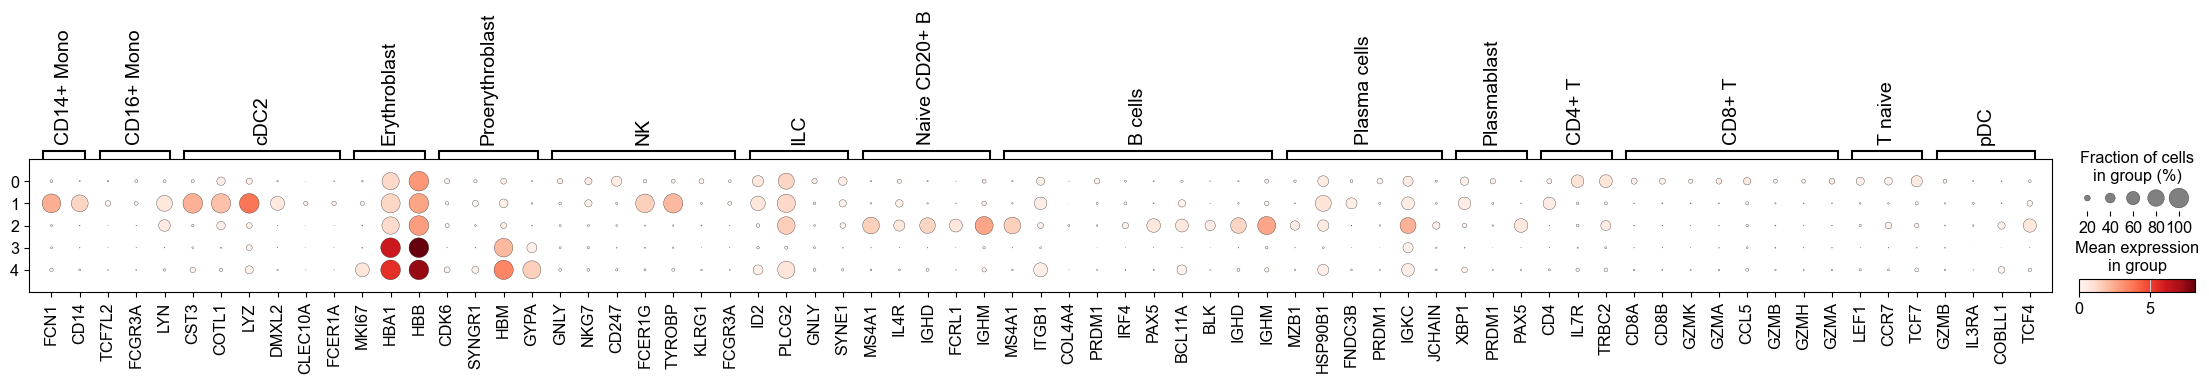

In [32]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_02")

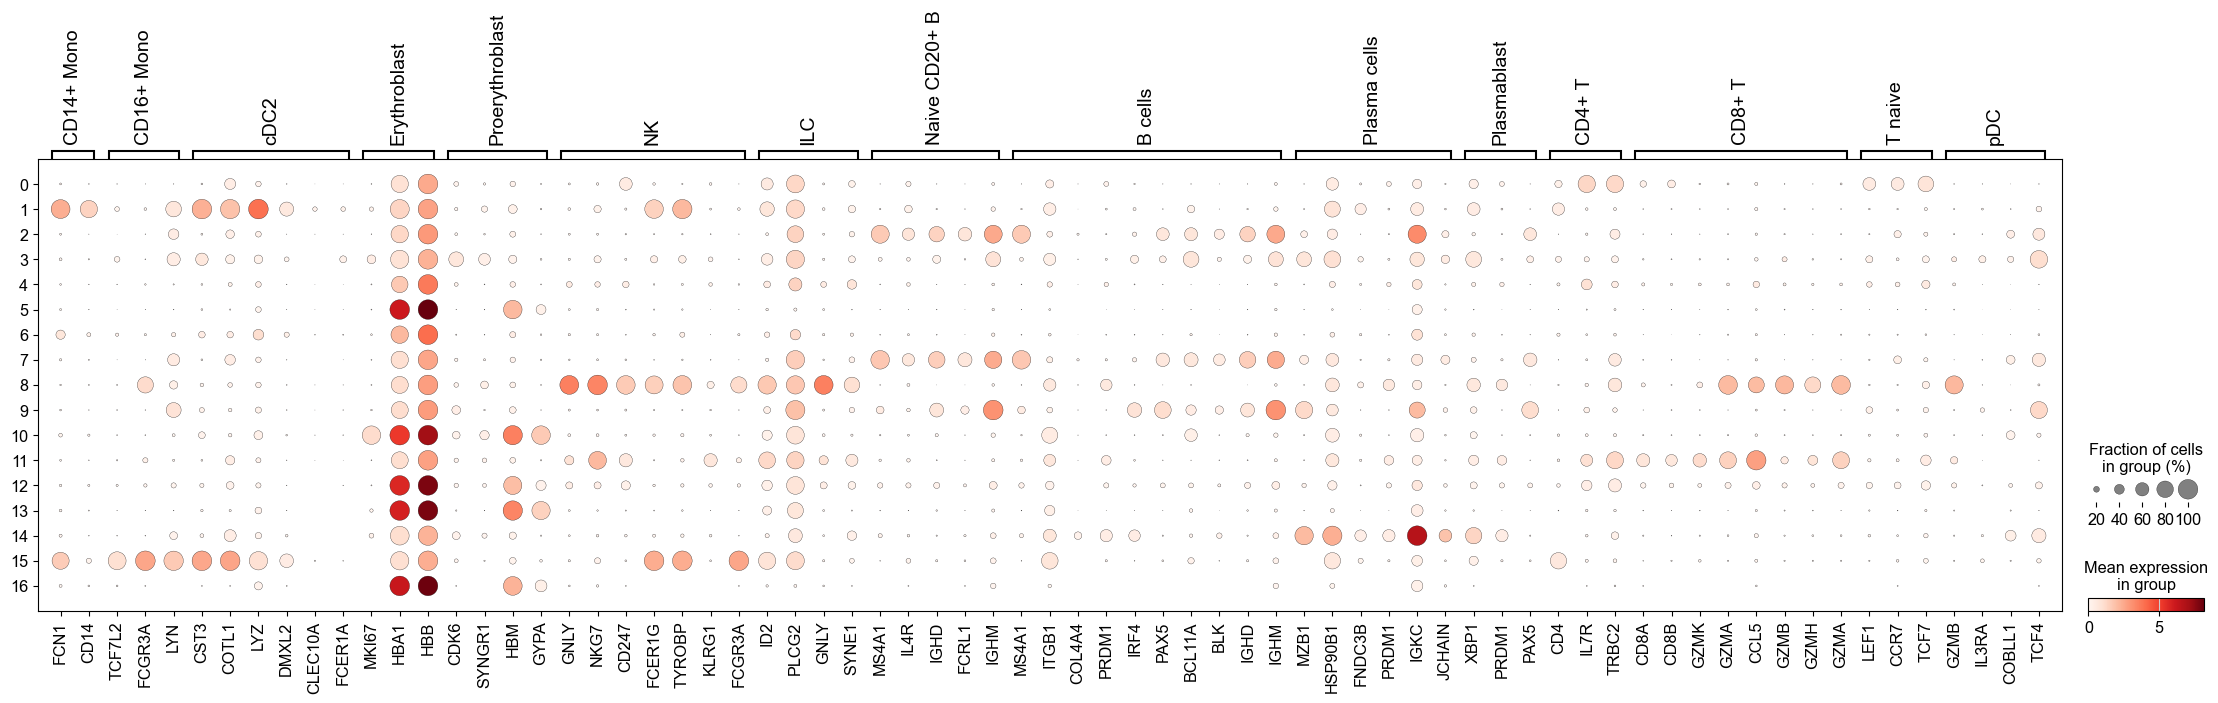

In [33]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_5")

### Previsão automática de rótulos 

In [34]:
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in C:\Users\Davi\.celltypist\data\models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


In [37]:
model = ct.models.Model.load(model="Immune_All_Low.pkl")
predictions = ct.annotate(adata, model="Immune_All_Low.pkl", majority_voting=True, over_clustering="leiden_res0_5")
# convert back to anndata||
adata = predictions.to_adata()

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 16828 cells and 23427 genes
🔗 Matching reference genes in the model
🧬 5852 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


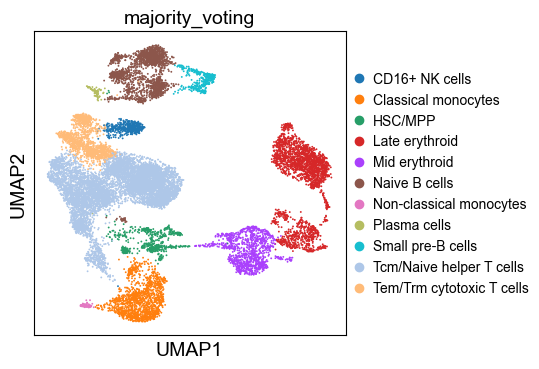

In [38]:
sc.pl.umap(adata, color="majority_voting", ncols=1)

### Anotação com análise de enriquecimento 

In [40]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")
# Keep canonical cell type markers alone
markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]
markers.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,
2,A2M,True,Bergmann glia,Ectoderm,True,0.0,0.062343,True,0.333333,0.001604,9606,Brain,0.012
4,A4GALT,True,Mast cells,Mesoderm,True,0.0,0.014133,True,0.000000,0.003023,9606,Immune system,0.005
5,A7KBS4,True,Embryonic stem cells,Epiblast,False,NaN,NaN,True,NaN,NaN,10090,Zygote,0.000
8,AANAT,True,Pinealocytes,Ectoderm,True,0.0,0.000000,True,0.000000,0.000000,9606,Brain,0.000
9,AANAT,True,Astrocytes,Ectoderm,True,0.0,0.000000,True,0.000000,0.000000,9606,Brain,0.000


In [41]:
dc.mt.mlm(adata, net=markers.rename(columns=dict(cell_type="source", genesymbol="target")), verbose=True)


mlm - Running mlm
Extracted omics mat with 16828 rows (observations) and 23427 columns (features)
weight not found in net.columns, adding it as:
net['weight'] = 1
Network adjacency matrix has 2390 unique features and 118 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

mlm - fitting 118 multivariate models of 23427 observations with 23308 degrees of freedom
mlm - done


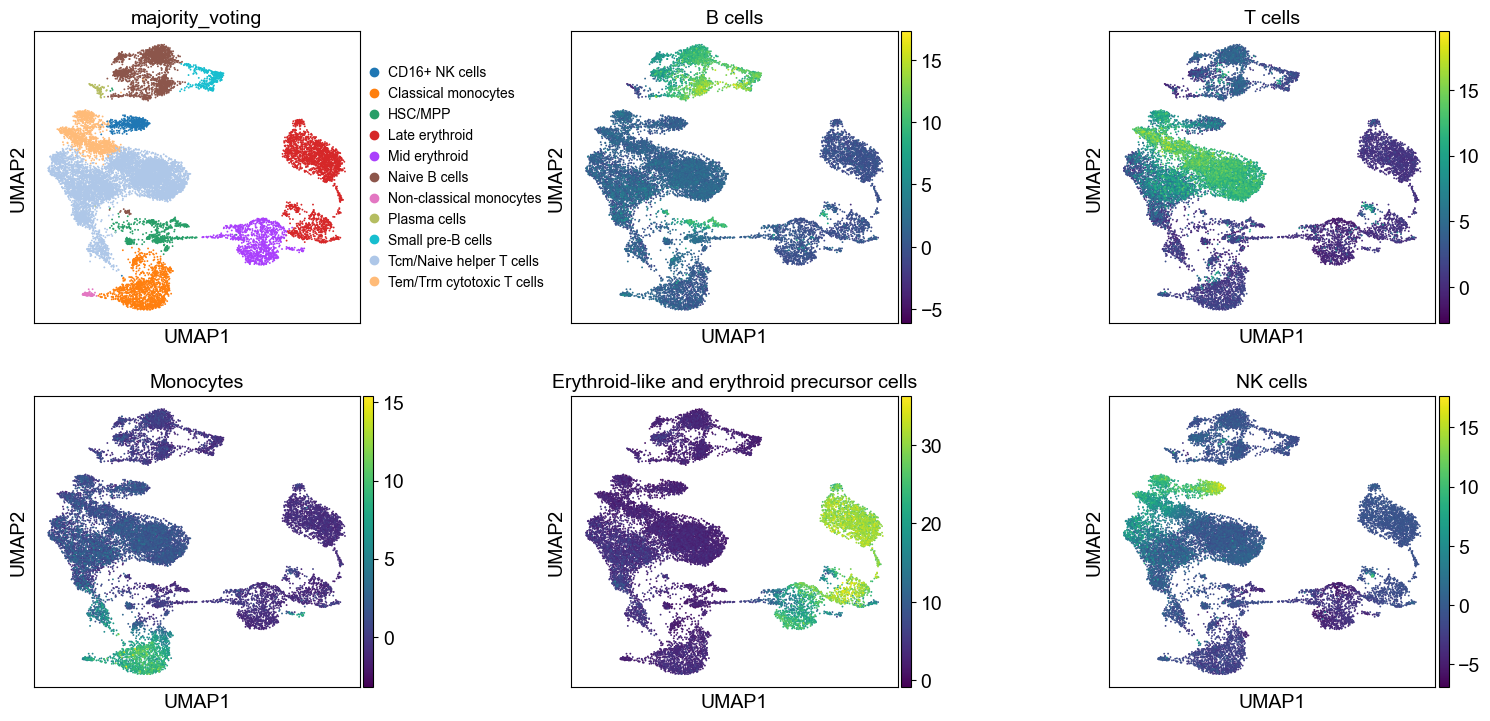

In [42]:
acts = dc.pp.get_obsm(adata, "score_mlm")
sc.pl.umap(
    acts,
    color=[
        "majority_voting",
        "B cells",
        "T cells",
        "Monocytes",
        "Erythroid-like and erythroid precursor cells",
        "NK cells",
    ],
    wspace=0.5,
    ncols=3,
)